# Segmentacion

### Carga inicial

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from src.utils import DEFAULT_TRAIN, add_features, clean_trips

%load_ext autoreload
%autoreload 2
plt.style.use("seaborn-v0_8-whitegrid")

raw = pd.read_csv(DEFAULT_TRAIN, parse_dates=["pickup_datetime"])
universe = clean_trips(add_features(raw))

N_SAMPLE = 40_000
SEED = 42
df = universe.sample(n=N_SAMPLE, random_state=SEED).reset_index(drop=True)
print("Muestra:", df.shape)

inside NYC bounding box             removed    633  (left 1458011)
duration between 1 min and 3 h      removed  10595  (left 1447416)
distance >= 0.1 km                  removed   7463  (left 1439953)
speed between 1 and 100 km/h        removed   1342  (left 1438611)
Total kept: 1438611/1458644 (98.6%)
Muestra: (40000, 16)


### Escalamiento

In [12]:
PARTITION_FEATURES = ["pickup_latitude", "pickup_longitude"]
X = df[PARTITION_FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

### EDA 

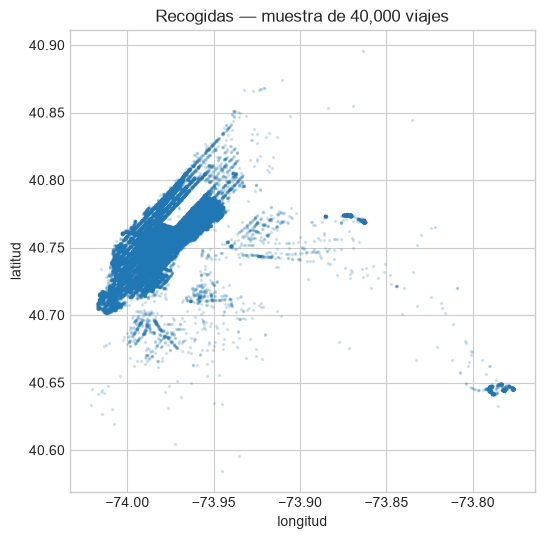

In [3]:
plt.figure(figsize=(6,6))
plt.scatter(df.pickup_longitude, df.pickup_latitude, s=2, alpha=0.15)
plt.xlabel("longitud"); plt.ylabel("latitud")
plt.title("Recogidas — muestra de 40,000 viajes")
plt.show()

### K-means

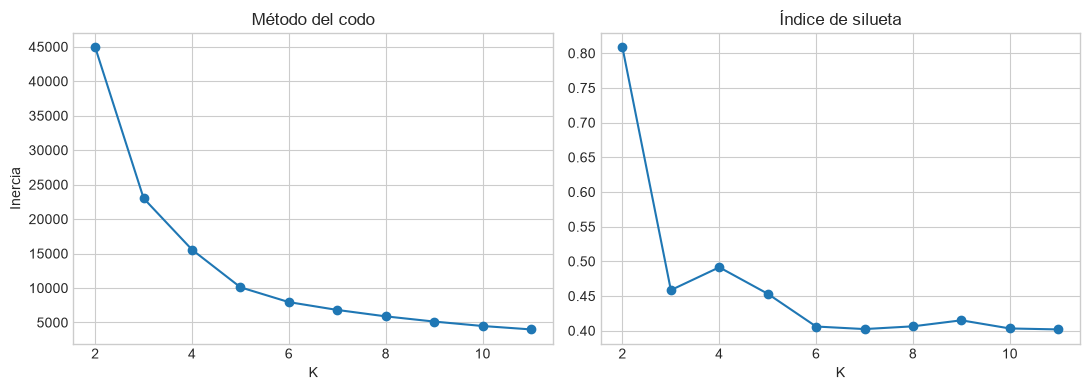

In [4]:
inertias, sils = [], []
K_range = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Método del codo"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(K_range), sils, marker="o")
axes[1].set_title("Índice de silueta"); axes[1].set_xlabel("K")
plt.tight_layout(); plt.show()

Elegimos K=4 al coincidir en el punto donde el codo de inercia comienza a aplanarse y con un maximo local en el indice de silueta de 0.49, Ofreciendo el mejor balance entre compacidad y numero de zonas accionable operativamente

In [13]:
K_FINAL = 4 
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=10).fit(X_scaled)
df["cluster_kmeans"] = kmeans_final.labels_

### DBSCAN

In [ ]:
eps_candidates = np.arange(0.10, 0.45, 0.02)
results = []

for eps in eps_candidates:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = 100 * n_noise / len(labels)
    
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = np.nan
    
    results.append({
        "eps": round(eps, 3),
        "n_clusters": n_clusters,
        "% ruido": round(pct_noise, 2),
        "silhouette": round(sil, 3) if not np.isnan(sil) else None
    })

sweep_df = pd.DataFrame(results)
sweep_df

,eps,n_clusters,% ruido,silhouette
0,0.10,24,0.67,0.015
1,0.12,21,0.53,0.048
2,0.14,20,0.41,0.035
3,0.16,15,0.31,0.046
4,0.18,13,0.25,0.045
5,0.20,9,0.22,0.388
6,0.22,10,0.18,0.547
7,0.24,9,0.16,0.499
8,0.26,8,0.15,0.504
9,0.28,6,0.13,0.543


In [24]:
EPS_FINAL = 0.32 

dbscan_final = DBSCAN(eps=EPS_FINAL, min_samples=MIN_SAMPLES).fit(X_scaled)
df["cluster_dbscan"] = dbscan_final.labels_

n_noise = (df["cluster_dbscan"] == -1).sum()
print(f"Puntos de ruido: {n_noise} ({n_noise/len(df):.1%})")

Puntos de ruido: 42 (0.1%)


### Tratamiento del ruido

In [25]:
noise_df = df[df["cluster_dbscan"] == -1]
print(noise_df[["pickup_latitude","pickup_longitude","distance_km","trip_duration"]].describe())

       pickup_latitude  pickup_longitude  distance_km  trip_duration
count        42.000000         42.000000    42.000000      42.000000
mean         40.701805        -73.897006     5.687741     929.023810
std           0.080422          0.071849     5.749589     895.702272
min          40.584476        -74.021088     0.328335     169.000000
25%          40.640438        -73.967405     1.921352     409.000000
50%          40.686829        -73.880630     2.982445     586.500000
75%          40.730392        -73.830622     5.995746    1042.500000
max          40.895546        -73.809189    19.587605    3769.000000


In [18]:
print("Referencia:")
print(df[["distance_km","trip_duration"]].mean())

Referencia:
distance_km        3.454794
trip_duration    837.796275
dtype: float64


La distancia promedio en los datos que se consideran ruido tienen en promedio una distancia de 5km y duran 929 segundos. A comparacion del promedio global podemos decir que son viajes mucho mas largos, probablemente hacen viajes a los aeropuertos o entre Boroughs. El modelo divide entre 4 custers que cubren el 99.9% de los viajes correctamente, por lo que no es necesario crear una estrategia nueva para los viajes no incluidos.

### Tabla comparativa de metricas

In [26]:
mask = df["cluster_dbscan"] != -1  # excluir ruido para métricas de DBSCAN

comparison = pd.DataFrame({
    "K-means": {
        "silhouette": silhouette_score(X_scaled, df["cluster_kmeans"]),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, df["cluster_kmeans"]),
        "davies_bouldin": davies_bouldin_score(X_scaled, df["cluster_kmeans"]),
        "n_clusters": df["cluster_kmeans"].nunique(),
    },
    "DBSCAN": {
        "silhouette": silhouette_score(X_scaled[mask], df.loc[mask, "cluster_dbscan"]),
        "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], df.loc[mask, "cluster_dbscan"]),
        "davies_bouldin": davies_bouldin_score(X_scaled[mask], df.loc[mask, "cluster_dbscan"]),
        "n_clusters": df.loc[mask, "cluster_dbscan"].nunique(),
    }
}).T
comparison

,silhouette,calinski_harabasz,davies_bouldin,n_clusters
K-means,0.491402,55248.568972,0.505496,4.0
DBSCAN,0.633275,10601.752709,0.209846,4.0


K means y DBSCAN coincien en identificar 4 concentraciones geograficas principales de demanda. La diferencia mas grande es que Kmeans produce zonas balanceadas entre si, lo que es lo mas adecuado para dividir territorios de asignacion operativa, mientras que DBSCAN produce clusters con cohesion interna, respetando la densidad. Cabe notar que Calinski-harabasz penaliza la desiguadad de tamaño entre clusters por lo que DBSCAN tiene una metrica menos favorable en ese aspecto

### Visualizacion de clusters

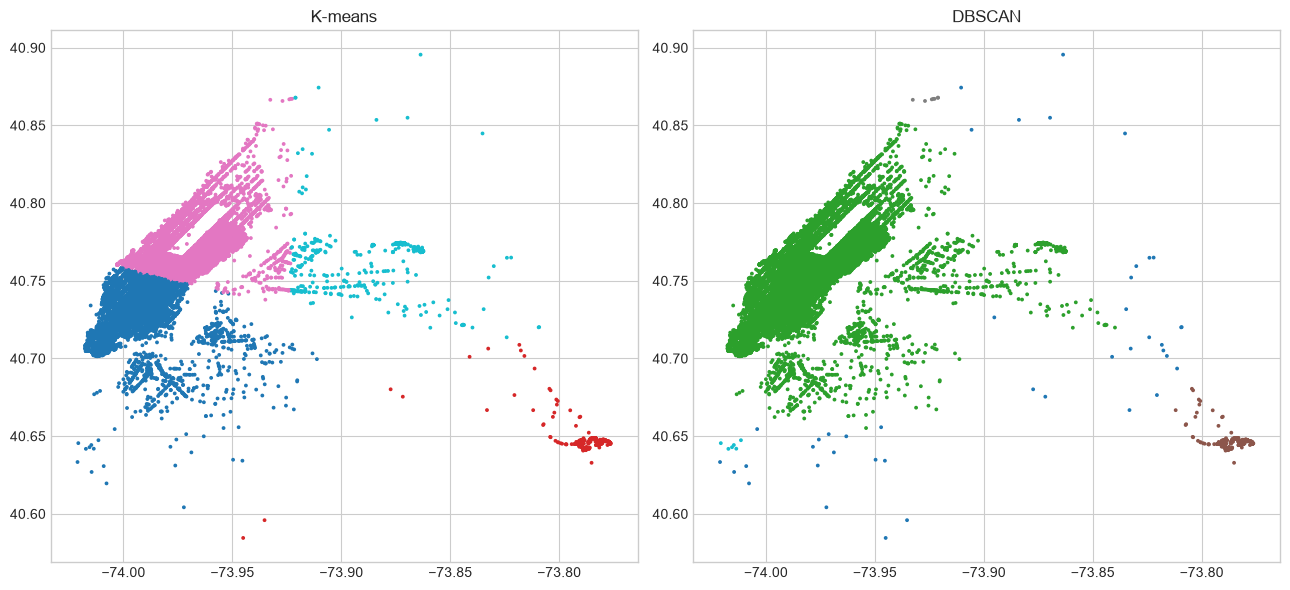

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13,6))
for ax, col, title in zip(axes, ["cluster_kmeans","cluster_dbscan"], ["K-means","DBSCAN"]):
    sc = ax.scatter(df.pickup_longitude, df.pickup_latitude, c=df[col], s=3, cmap="tab10")
    ax.set_title(title)
plt.tight_layout(); plt.show()

K-means impone una partición basada en centroides, lo que le permite dividir el territorio en 4 zonas operativamente distintas y de tamaño manejable. DBSCAN, en cambio, sufre el efecto de encadenamiento: como Manhattan y Queens occidental están conectados por una densidad continua de recogidas a lo largo de las vías principales

### Recomendacion de negocio
1. Manhattan bajo/medio tiene alta densidad por lo que se recomienda mantener ahi la flota base
2. Manhattan alto tiene demanda dispersa a lo largo del corredor norte a sur, por lo que seria efectivo posicionar conductores alrededor de ese eje en vez de en un punto especifico
3. Queens occidental tiene demana igada a aeropuerto de LaGuardia, por o que lo mejor seria sincronizar operaciones con horarios de vuelos
4. JFK tiene un cluster aislado y bastante compacto por lo que se justifica tener una zona de espera cerca de este aeropuerto